Goal: Determine discrete number of photons arriving

# Glossary:

- pedestal: background image taken in a different run
- intra-dark: every other pulse that doesn't include x-ray pulses

# imports

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (20,8)
mpl.rcParams['font.size'] = 20
from matplotlib.colors import LogNorm
from extra_data import open_run
import numpy as np

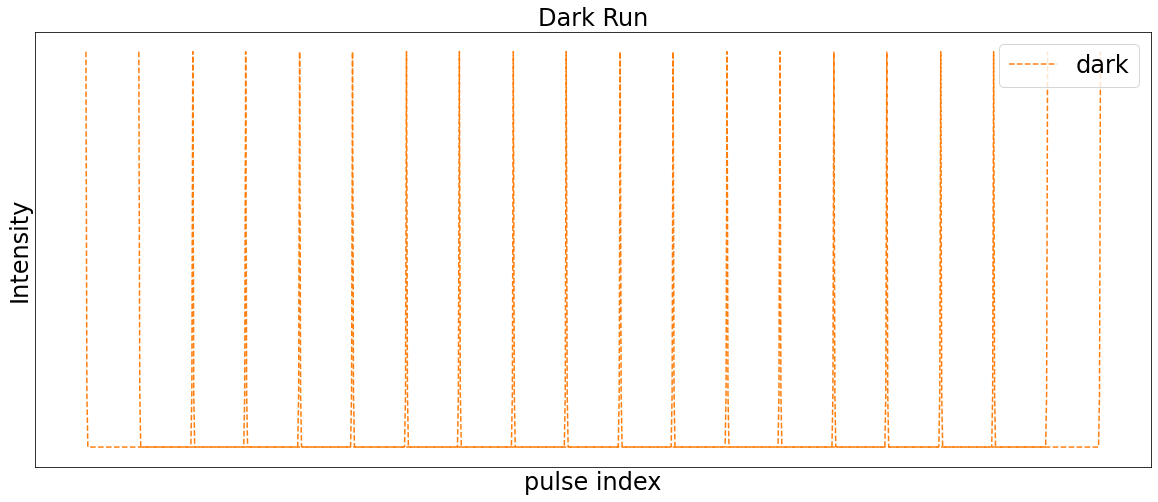

In [2]:
# Define the parameters of the Gaussian distribution
mu = 0  # Mean (will be shifted for each distribution)
sigma = 0.1  # Standard deviation

# Generate x values for the line
x_line = np.linspace(0, 200, 1000)

# Generate x values for the Gaussian distributions
x_gaussian = np.linspace(0, 200, 10)

# Create a 2D array to store the y values for the Gaussian distributions
y_gaussian = np.zeros((len(x_line), len(x_gaussian)))

# Calculate the y values for the Gaussian distributions
for i, mu_i in enumerate(x_gaussian):
    y_gaussian[:, i] = np.exp(-((x_line - mu_i) / sigma)**2 / 2) / (sigma * np.sqrt(2 * np.pi))

# Create the plot
plt.plot(x_line, np.sum(y_gaussian, axis=1), 'C1--')
plt.plot(x_line + 11, np.sum(y_gaussian, axis=1), 'C1--', label='dark')
plt.xticks([])
plt.yticks([])
plt.xlabel('pulse index', fontsize=24)
plt.ylabel('Intensity', fontsize=24)
plt.title('Dark Run', fontsize=24)
plt.legend(loc='upper right', fontsize=24)
plt.show()

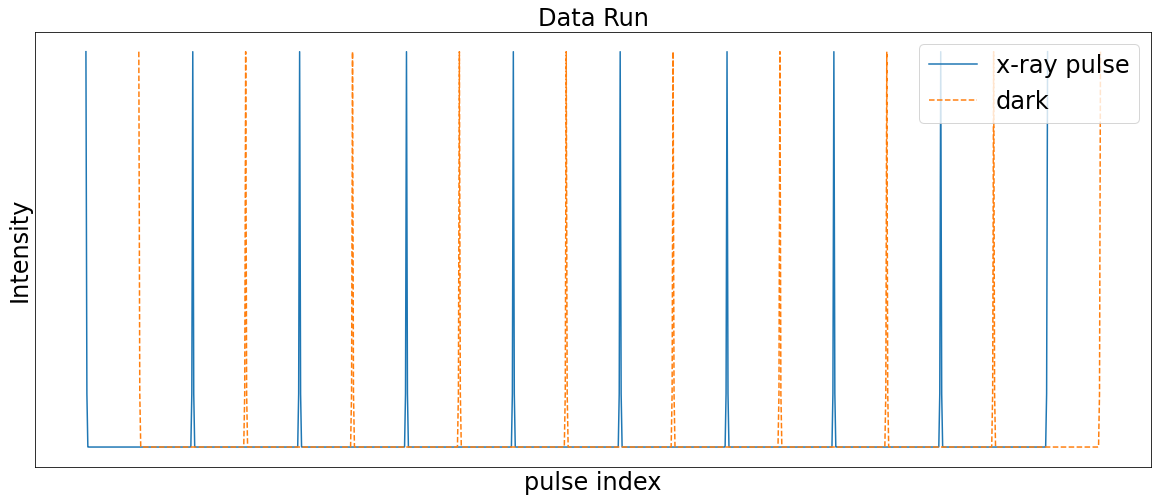

In [3]:
# Define the parameters of the Gaussian distribution
mu = 0  # Mean (will be shifted for each distribution)
sigma = 0.1  # Standard deviation

# Generate x values for the line
x_line = np.linspace(0, 200, 1000)

# Generate x values for the Gaussian distributions
x_gaussian = np.linspace(0, 200, 10)

# Create a 2D array to store the y values for the Gaussian distributions
y_gaussian = np.zeros((len(x_line), len(x_gaussian)))

# Calculate the y values for the Gaussian distributions
for i, mu_i in enumerate(x_gaussian):
    y_gaussian[:, i] = np.exp(-((x_line - mu_i) / sigma)**2 / 2) / (sigma * np.sqrt(2 * np.pi))

# Create the plot
plt.plot(x_line, np.sum(y_gaussian, axis=1), 'C0', label='x-ray pulse')
plt.plot(x_line + 11, np.sum(y_gaussian, axis=1), 'C1--', label='dark')
plt.xticks([])
plt.yticks([])
plt.xlabel('pulse index', fontsize=24)
plt.ylabel('Intensity', fontsize=24)
plt.title('Data Run', fontsize=24)
plt.legend(loc='upper right', fontsize=24)
plt.show()

# Load metadata

In [4]:
run = 70
dark_run = 69
proposal = 2884
gain = 0.199142159721309
module = 0
pulses_per_train = 400

# raw data

In [6]:
run_ed = open_run(proposal=proposal, run=run)
dark_run_ed = open_run(proposal=proposal, run=dark_run)

source = f'SCS_DET_DSSC1M-1/DET/{module}CH0:xtdf'
counts = run_ed.get_data_counts(source, 'image.data')

source_dark = f'SCS_DET_DSSC1M-1/DET/{module}CH0:xtdf'
counts_dark = dark_run_ed.get_data_counts(source_dark, 'image.data')

arr = run_ed.get_dask_array(source, 'image.data')[:, :1]
arr_dark = dark_run_ed.get_dask_array(source_dark, 'image.data')[:, :1]
# Make a new dimension for trains
arr_trains = arr.reshape(-1, pulses_per_train, 128, 512)
arr_trains_dark = arr_dark.reshape(-1, pulses_per_train, 128, 512)

In [7]:
arr_trains

,Array,Chunk
Bytes,948.38 GB,1.68 GB
Shape,"(18089, 400, 128, 512)","(32, 400, 128, 512)"
Count,2331 Tasks,568 Chunks
Type,uint16,numpy.ndarray


In [8]:
arr_trains_dark

dask.array<reshape, shape=(656, 400, 128, 512), dtype=uint16, chunksize=(36, 400, 128, 512), chunktype=numpy.ndarray>

warning: data is in uint16 format

In [9]:
arr = arr_trains[:100].compute().astype(float)
arr_dark = arr_trains_dark[:100].compute().astype(float)

In [10]:
sum_arr = arr.sum(axis=(0,1))
sum_dark = arr_dark.sum(axis=(0,1))
pedastal = arr_dark.mean(axis=(0))

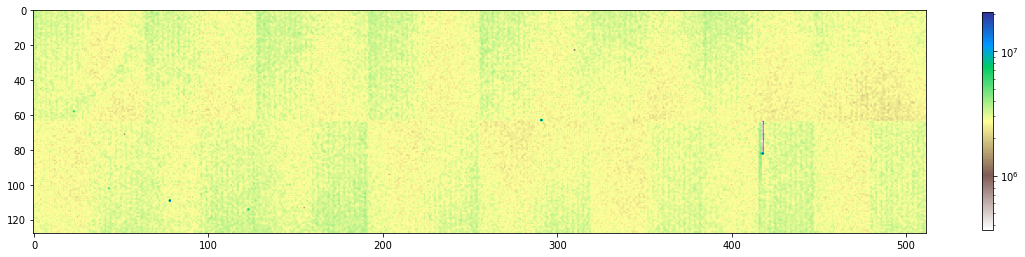

In [11]:
img = sum_arr

plt.figure()
plt.imshow(img, cmap='terrain_r', norm=LogNorm())
plt.colorbar(shrink=0.5)
plt.show()

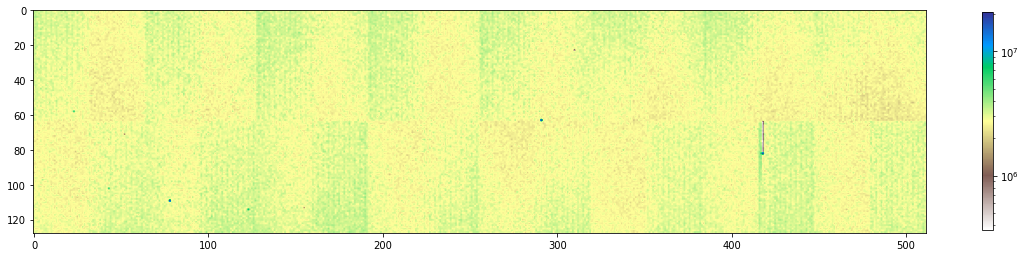

In [12]:
img = sum_dark

plt.figure()
plt.imshow(img, cmap='terrain_r', norm=LogNorm())
plt.colorbar(shrink=0.5)
plt.show()

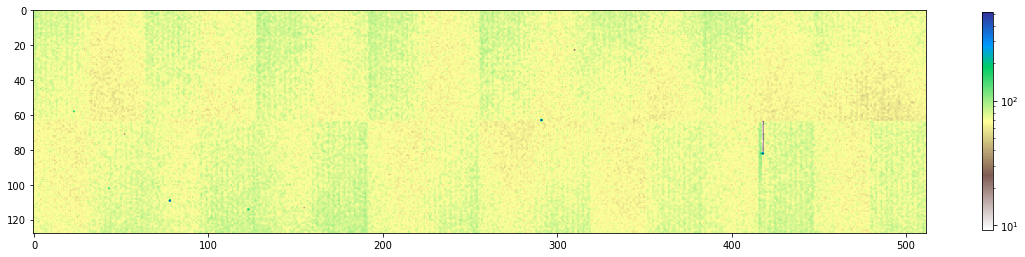

In [14]:
img = pedastal.mean(axis=0)

plt.figure()
plt.imshow(img, cmap='terrain_r', norm=LogNorm())
plt.colorbar(shrink=0.5)
plt.show()

In [15]:
arr.shape

(100, 400, 128, 512)

In [19]:
arr_sub_ped = arr - np.expand_dims(pedastal, axis=(0))

In [20]:
arr_sub_ped_mean = arr_sub_ped[:,::2].mean(axis=(0,1))

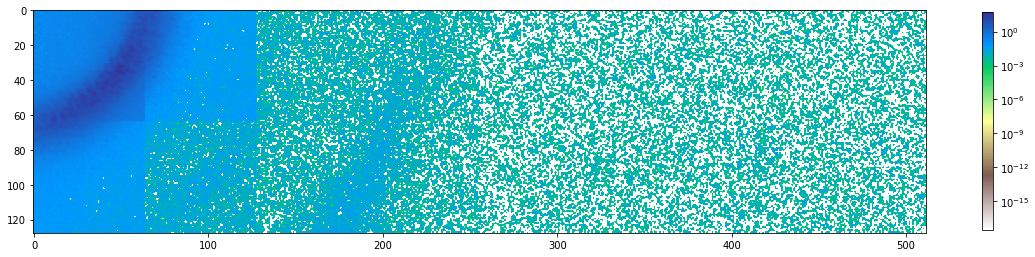

In [21]:
img = arr_sub_ped_mean

plt.figure()
plt.imshow(img, cmap='terrain_r', norm=LogNorm())
plt.colorbar(shrink=0.5)
plt.show()

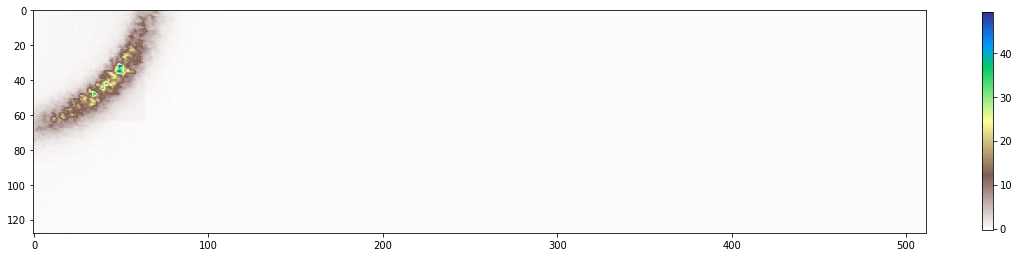

In [22]:
img = arr_sub_ped_mean

plt.figure()
plt.imshow(img, cmap='terrain_r')
plt.colorbar(shrink=0.5)
plt.show()

In [23]:
arr_sub_ped_inter = arr_sub_ped[:,::2] - arr_sub_ped[:,1::2]

In [26]:
arr_sub_ped_inter.shape

(100, 200, 128, 512)

In [27]:
arr_sub_ped_mean = arr_sub_ped_inter.mean(axis=(0,1))

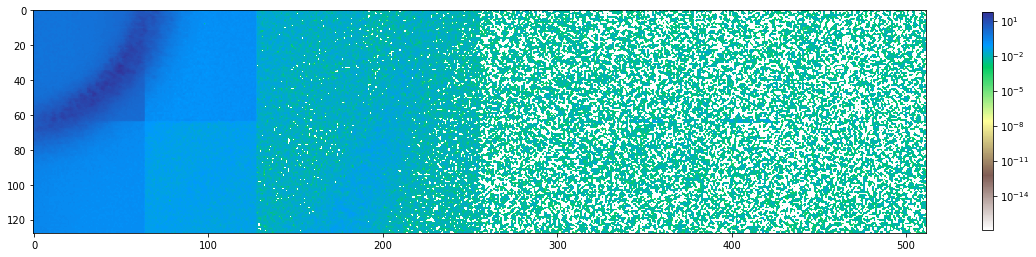

In [28]:
img = arr_sub_ped_mean

plt.figure()
plt.imshow(img, cmap='terrain_r', norm=LogNorm())
plt.colorbar(shrink=0.5)
plt.show()

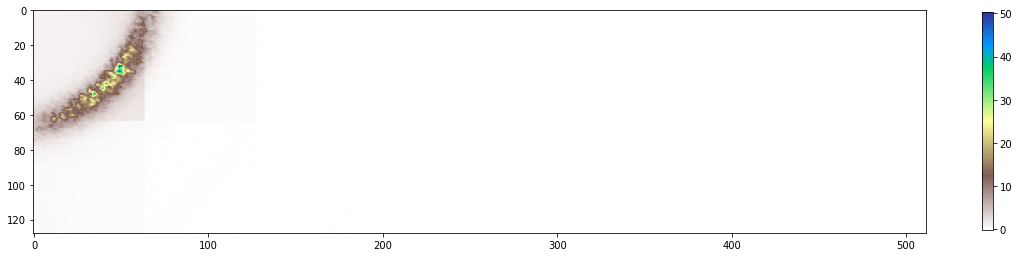

In [29]:
img = arr_sub_ped_mean

plt.figure()
plt.imshow(img, cmap='terrain_r')
plt.colorbar(shrink=0.5)
plt.show()

In [30]:
gain

0.199142159721309

In [31]:
arr_gain = arr_sub_ped_inter * gain

In [32]:
arr_gain_mean = arr_gain.mean(axis=(0,1))

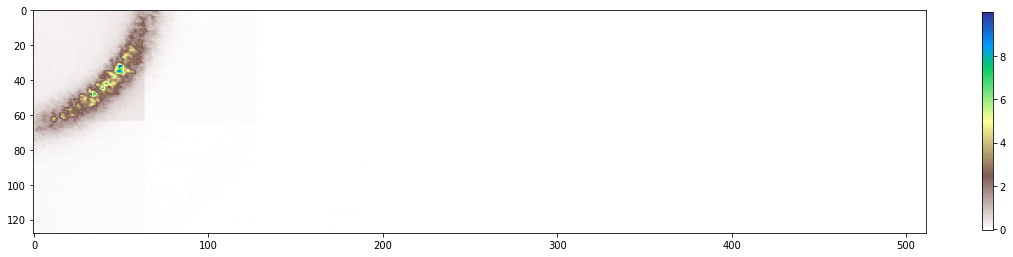

In [33]:
img = arr_gain_mean

plt.figure()
plt.imshow(img, cmap='terrain_r')
plt.colorbar(shrink=0.5)
plt.show()

In [41]:
arr_gain_discrete = arr_gain.copy()

arr_gain_discrete = np.clip(arr_gain_discrete, 0, 255)
arr_gain_discrete = arr_gain_discrete.astype(np.uint8)

In [42]:
arr_gain_discrete_mean = arr_gain_discrete.mean(axis=(0,1))

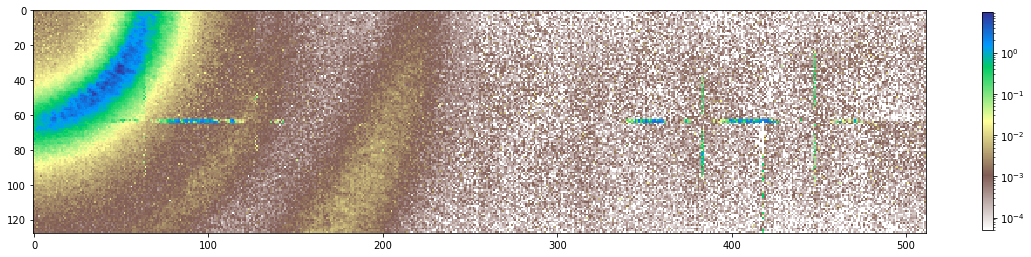

In [43]:
img = arr_gain_discrete_mean

plt.figure()
plt.imshow(img, cmap='terrain_r', norm=LogNorm(), interpolation='nearest')
plt.colorbar(shrink=0.5)
plt.show()

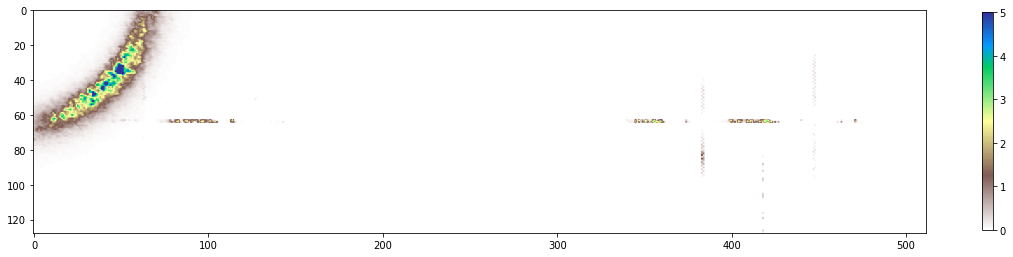

In [45]:
img = arr_gain_discrete_mean

plt.figure()
plt.imshow(img, cmap='terrain_r', vmax=5)
plt.colorbar(shrink=0.5)
plt.show()

In [46]:
arr_gain_discrete_std = arr_gain_discrete.std(axis=(0,1))

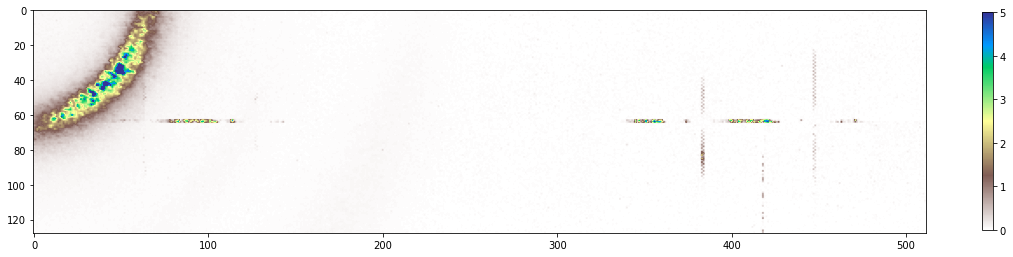

In [47]:
img = arr_gain_discrete_std

plt.figure()
plt.imshow(img, cmap='terrain_r', vmax=5)
plt.colorbar(shrink=0.5)
plt.show()

# conclusion

In [ ]:
dark_run_ed = open_run(proposal=proposal, run=dark_run)
arr_dark = dark_run_ed.get_dask_array(f'SCS_DET_DSSC1M-1/DET/{module}CH0:xtdf', 'image.data')[:, 0]
arr_dark = arr_dark.reshape(-1, pulses_per_train, 128, 512)
pedastal = arr_trains_dark.compute().astype(float).mean(axis=0)


run_ed = open_run(proposal=proposal, run=run)
arr = run_ed.get_dask_array(f'SCS_DET_DSSC1M-1/DET/{module}CH0:xtdf', 'image.data')[:, 0]
arr = arr.reshape(-1, pulses_per_train, 128, 512)
arr = arr.astype(float)
arr = arr - np.expand_dims(pedastal, axis=(0))
arr = arr[:,::2] - arr[:,1::2]
arr = arr * gain
arr = np.clip(arr, 0, 255)
arr = arr.astype(np.uint8)

# correlation to xgm

In [5]:
run, module

(70, 0)

In [6]:
import toolbox_scs as tb

run_obj, v = tb.load(proposal, run, ['SCS_XGM'])
xgm = v.SCS_SA3.data

In [7]:
xgm

array([[346.51171875, 177.0809021 , 213.50878906, ..., 160.83615112,
        406.88555908, 136.47680664],
       [234.45649719, 132.9118042 , 208.32354736, ..., 248.80317688,
        308.87695312, 270.9755249 ],
       [ 93.98129272, 100.40895844, 146.49169922, ..., 445.21594238,
        219.52749634, 199.53106689],
       ...,
       [221.63841248, 189.2449646 ,  80.60931396, ..., 257.48599243,
        151.81137085, 109.97066498],
       [271.50250244, 210.14532471, 216.26283264, ..., 361.12368774,
        529.85705566, 453.19277954],
       [246.60379028,  43.98426437, 198.98765564, ..., 226.66748047,
        214.92114258,  99.96807861]])

In [8]:
xgm.shape

(18082, 200)

In [9]:
import h5py

file = f'../data/photon_maps/run{run:03d}_module{module:02d}.h5'
with h5py.File(file, 'r', ) as f:
    print(f.keys())
    print(f['photon_maps'].shape)

<KeysViewHDF5 ['integrated_intensity', 'photon_maps']>
(18089, 200, 128, 512)


In [10]:
with h5py.File(file, 'r', ) as f:
    imgs = f['photon_maps'][:300]

In [11]:
imgs.shape

(300, 200, 128, 512)

In [12]:
intensity = imgs.sum(axis=(2,3))

In [14]:
from scipy.optimize import curve_fit

def fit_LS_b(func, x, y, initial_guess):
    popt,pcov = curve_fit(func, x, y, p0=initial_guess, maxfev=1000000)
    popt,pcov = curve_fit(func, x, y, p0=popt, maxfev=1000000)
    perr = np.sqrt(np.diag(pcov))
    fitted_parameters = np.zeros([len(initial_guess), 2])
    fitted_parameters[:, 0] = popt
    fitted_parameters[:, 1]= perr
    return fitted_parameters

def poly1(x, k1, k0):
    return k1*x+k0

In [15]:
xgm[:300].shape, intensity.shape

((300, 200), (300, 200))

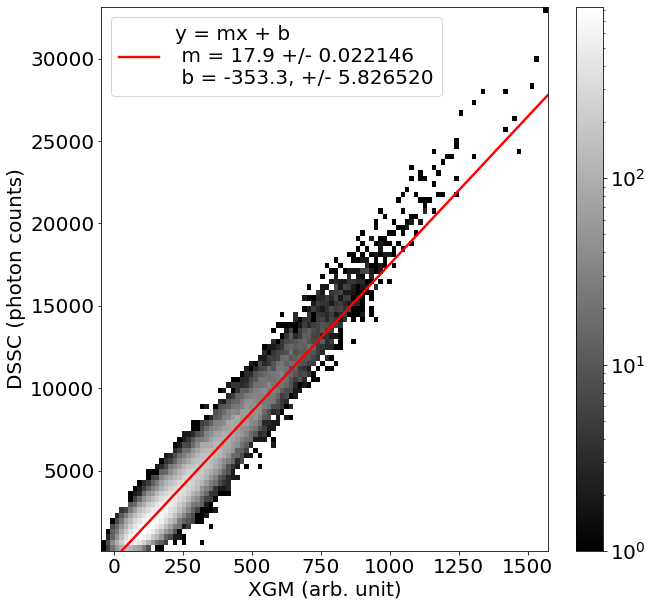

In [40]:
from matplotlib.colors import LogNorm

# Mismatch occurs in group 10, train 106
x = xgm[:300].flatten()
y = intensity.flatten()

x_plot = np.linspace(0, x.max(),100)

plt.figure(figsize=(10,10))
plt.hist2d(x, y, bins=(100,100), norm=LogNorm(), cmap='gray')
p = fit_LS_b(poly1,x[x<5000],y[x<5000],[10,0.1])
plt.plot(x_plot, poly1(x_plot, *p[:,0]), 'r-', lw=2.4, label=f'y = mx + b \n m = {p[0,0]:.1f} +/- {p[0,1]:1f}\n b = {p[1,0]:.1f}, +/- {p[1,1]:1f}')
plt.colorbar()
plt.legend(loc='upper left')
plt.xlabel('XGM (arb. unit)')
plt.ylabel('DSSC (photon counts)')
# plt.yscale('log')
# plt.xscale('log')
plt.show()

In [41]:
p

array([[ 1.78878123e+01,  2.21461414e-02],
       [-3.53316482e+02,  5.82652005e+00]])